# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [59]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [60]:
import pandas as pd

# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
df = pd.read_csv('Data/marketing_offer_data.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())



Number of samples: 1000
Number of features: 8
Example data:
   tenure_months  base_engagement  initial_offer  followup_engagement  \
0             39                0              0                    1   
1             52                1              1                    0   
2             29                1              1                    1   
3             15                1              1                    0   
4             43                1              0                    1   

   special_offer  purchase region  noise_factor  
0              1         0   West     -0.443321  
1              0         0  North     -0.160936  
2              0         1  South      2.138209  
3              1         1  North      1.318105  
4              0         0  South      0.132348  


In [61]:
import pandas as pd

col_desc = pd.DataFrame({
    "column_name": [
        "tenure_months","base_engagement","initial_offer","followup_engagement","special_offer","purchase","region","noise_factor"],
    "description": [
        "How many months the customer has been with the company.","Baseline engagement before any offer is applied.",
        "The first marketing offer or treatment assigned to the customer.","Engagement measured after the initial offer.",
        "A second or stronger offer shown to the customer.","Final outcome indicating whether a purchase happened.",
        "Customer region or geographic segment.","Random or synthetic noise variable used to make the data less clean.",
    ]
})
col_desc

,column_name,description
0,tenure_months,How many months the customer has been with the...
1,base_engagement,Baseline engagement before any offer is applied.
2,initial_offer,The first marketing offer or treatment assigne...
3,followup_engagement,Engagement measured after the initial offer.
4,special_offer,A second or stronger offer shown to the customer.
5,purchase,Final outcome indicating whether a purchase ha...
6,region,Customer region or geographic segment.
7,noise_factor,Random or synthetic noise variable used to mak...


| Role        | Columns                                                                                                                   | Why                                                                                                                                                                                  |
| ----------- | ------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Treatment   | initial_offer, possibly special_offer                                                                                     | These are the intervention variables we want to study.                                                                                                                              |
| Outcome     | purchase                                                                                                                  | This is the final response we care about.                                                                                                                                           |
| Confounders | tenure_months, base_engagement, region                                                                                    | These likely affect both offer assignment and purchase behavior.                                                                                                                     |
| Mediators   | followup_engagement                                                                                                       | This is likely affected by the offer and may then affect purchase.                                                                                                                   |
| Colliders   | followup_engagement could also be a collider in some designs; noise_factor is usually neither a confounder nor a collider | Collider status depends on the causal story, not just the column name. noise_factor is usually just irrelevant noise unless the data-generating process links it to other variables. |

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tenure_months        1000 non-null   int64  
 1   base_engagement      1000 non-null   int64  
 2   initial_offer        1000 non-null   int64  
 3   followup_engagement  1000 non-null   int64  
 4   special_offer        1000 non-null   int64  
 5   purchase             1000 non-null   int64  
 6   region               1000 non-null   str    
 7   noise_factor         1000 non-null   float64
dtypes: float64(1), int64(6), str(1)
memory usage: 62.6 KB


In [63]:
df.describe()

,tenure_months,base_engagement,initial_offer,followup_engagement,special_offer,purchase,noise_factor
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,30.582000,0.534000,0.271000,0.516000,0.321000,0.458000,-0.008893
std,17.024838,0.499092,0.444699,0.499994,0.467094,0.498482,1.018453
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.708797
25%,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.737244
50%,31.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.014634
75%,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.737984
max,59.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.840886


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [64]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


tenure_months          0
base_engagement        0
initial_offer          0
followup_engagement    0
special_offer          0
purchase               0
region                 0
noise_factor           0
dtype: int64

In [65]:
# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


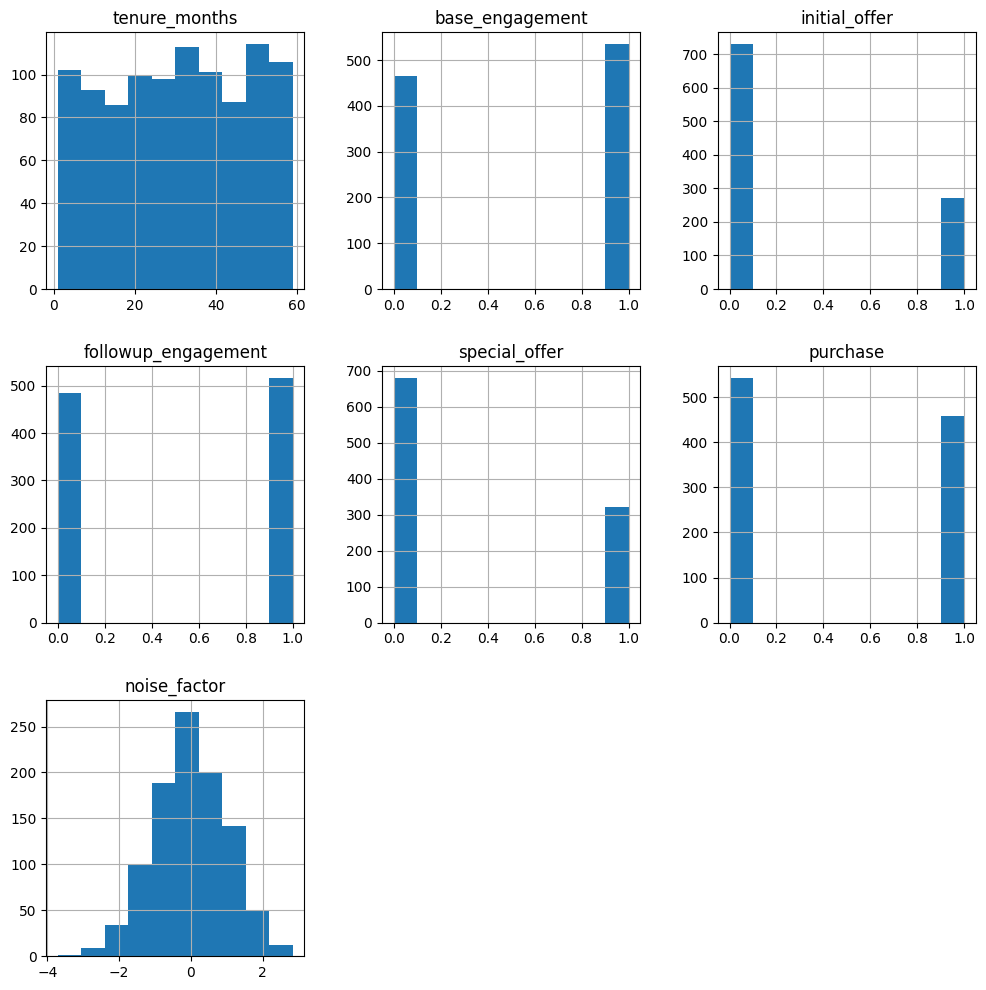

In [66]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


In [55]:
#Pie chart of region
# make north 1, south 2, east 3, west 4
# df['region'] = df['region'].map({'North': 1, 'South': 2, 'East': 3, 'West': 4})
region_counts = df['region'].value_counts()


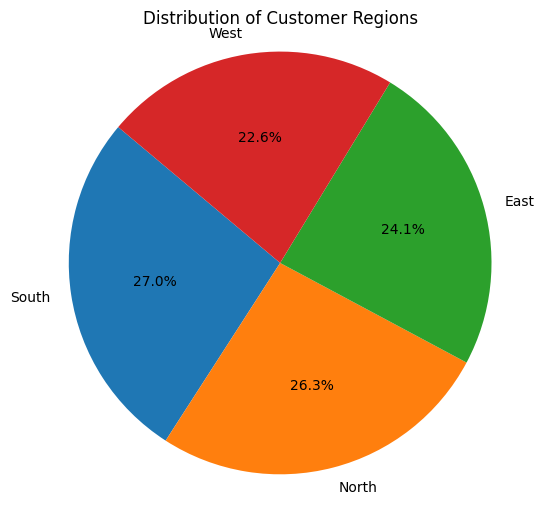

In [67]:
plt.figure(figsize=(6, 6))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customer Regions')
plt.axis('equal')
plt.show()

## Data transformation

In [68]:
df.head()

,tenure_months,base_engagement,initial_offer,followup_engagement,special_offer,purchase,region,noise_factor
0,39,0,0,1,1,0,West,-0.443321
1,52,1,1,0,0,0,North,-0.160936
2,29,1,1,1,0,1,South,2.138209
3,15,1,1,0,1,1,North,1.318105
4,43,1,0,1,0,0,South,0.132348


In [69]:
df['region'] = df['region'].map({'North': 1, 'South': 2, 'East': 3, 'West': 4})
df['region'].value_counts()

region
2    270
1    263
3    241
4    226
Name: count, dtype: int64

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


#### Region can be a confounder, so we want to check how purchase distribution varies by region


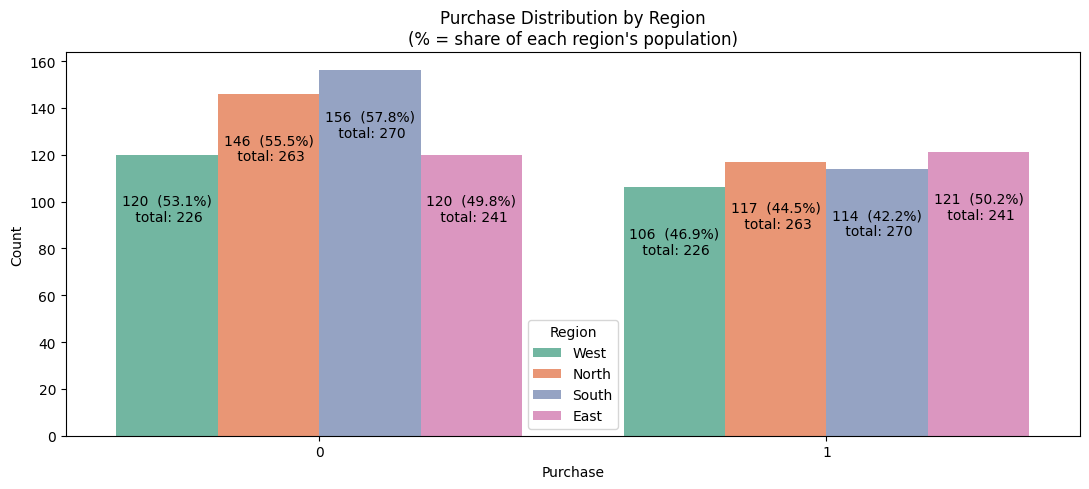

In [112]:
region_temp = df['region'].map({1: 'North', 2: 'South', 3: 'East', 4: 'West'})
df['region_label'] = region_temp
region_counts = df['region_label'].value_counts()

plt.figure(figsize=(11, 5))
ax = sns.countplot(x='purchase', hue=region_temp, data=df, palette='Set2')

# get region names in the same order as the containers
region_names = [t.get_text() for t in ax.legend_.texts]

for container, region_name in zip(ax.containers, region_names):
    labels = []
    for bar in container:
        height = bar.get_height()
        region_total = region_counts[region_name]
        pct = height / region_total * 100
        labels.append(f'{int(height)}  ({pct:.1f}%)\n total: {region_total}')
    ax.bar_label(container, labels=labels, padding=-50)
plt.title("Purchase Distribution by Region\n(% = share of each region's population)")
plt.xlabel('Purchase')
plt.ylabel('Count')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

In [114]:
# purchase rate by region
print(df.groupby('region_label')['purchase'].mean())

# special_offer rate by region  
print(df.groupby('region_label')['special_offer'].mean())

region_label
East     0.502075
North    0.444867
South    0.422222
West     0.469027
Name: purchase, dtype: float64
region_label
East     0.298755
North    0.357414
South    0.296296
West     0.331858
Name: special_offer, dtype: float64


In [118]:
# raw counts across all 4 combinations
joint = pd.crosstab(df['initial_offer'], df['special_offer'], margins=True)
print("Joint counts:")
# print(joint)
joint

Joint counts:


special_offer,0,1,All
initial_offer,,,
0,559,170,729
1,120,151,271
All,679,321,1000


In [119]:
# as proportions
joint_pct = pd.crosstab(df['initial_offer'], df['special_offer'], 
                         normalize='all').round(3) * 100
print("\nJoint proportions (% of total):")
joint_pct


Joint proportions (% of total):


special_offer,0,1
initial_offer,,
0,55.9,17.0
1,12.0,15.1


In [120]:
# does receiving special_offer depend on initial_offer?
print("special_offer rate by initial_offer:")
print(df.groupby('initial_offer')['special_offer'].mean().round(3))

special_offer rate by initial_offer:
initial_offer
0    0.233
1    0.557
Name: special_offer, dtype: float64


In [123]:
df['tenure_bin'] = pd.qcut(df['tenure_months'], q=4,
                            labels=['0-15', '15-30', '30-45', '45-60'])

df['noise_bin'] = pd.qcut(df['noise_factor'], q=4,
                           labels=['very_low', 'low', 'high', 'very_high'])

In [124]:
covariates = ['base_engagement', 'followup_engagement', 
              'tenure_bin', 'noise_bin', 'region']

for treatment in ['initial_offer', 'special_offer']:
    print(f"\n{'='*50}")
    print(f"Positivity check for: {treatment}")
    print(f"{'='*50}")
    for col in covariates:
        ct = pd.crosstab(df[col], df[treatment], normalize='index').round(2)
        print(f"\n  --- {col} ---")
        print(ct)


Positivity check for: initial_offer

  --- base_engagement ---
initial_offer       0     1
base_engagement            
0                0.78  0.22
1                0.69  0.31

  --- followup_engagement ---
initial_offer           0     1
followup_engagement            
0                    0.68  0.32
1                    0.78  0.22

  --- tenure_bin ---
initial_offer     0     1
tenure_bin               
0-15           0.49  0.51
15-30          0.68  0.32
30-45          0.83  0.17
45-60          0.91  0.09

  --- noise_bin ---
initial_offer     0     1
noise_bin                
very_low       0.76  0.24
low            0.70  0.30
high           0.72  0.28
very_high      0.74  0.26

  --- region ---
initial_offer     0     1
region                   
1              0.70  0.30
2              0.75  0.25
3              0.77  0.23
4              0.69  0.31

Positivity check for: special_offer

  --- base_engagement ---
special_offer       0     1
base_engagement            
0               

**Positivity Check — `tenure_bin`**

---

**Treatment: `initial_offer`**

| tenure_bin | No Initial Offer (0) | Got Initial Offer (1) | Concern |
|---|---|---|---|
| 0-15 | 0.49 | 0.51 | ✅ Near 50/50 split |
| 15-30 | 0.68 | 0.32 | ✅ Acceptable |
| 30-45 | 0.83 | 0.17 | ⚠️ Only 17% got offer |
| 45-60 | 0.91 | 0.09 | ❌ Very few got offer |

**Reading:** Newer customers (0-15 months) have a fair chance of receiving `initial_offer`. But as tenure increases, the probability of getting an offer drops sharply — long-tenure customers (45-60 months) almost never receive it (9%). Causal estimates for that group are unreliable.

---

**Treatment: `special_offer`**

| tenure_bin | No Special Offer (0) | Got Special Offer (1) | Concern |
|---|---|---|---|
| 0-15 | 0.36 | 0.64 | ✅ Good overlap |
| 15-30 | 0.61 | 0.39 | ✅ Acceptable |
| 30-45 | 0.85 | 0.15 | ⚠️ Only 15% got offer |
| 45-60 | 0.90 | 0.10 | ❌ Very few got offer |

**Reading:** Same pattern — newer customers are heavily targeted with `special_offer`, while long-tenure customers rarely receive it. This is consistent across both treatments, suggesting **tenure is a strong driver of treatment assignment** overall.

---

**Key takeaway across both treatments**

| tenure_bin | Verdict |
|---|---|
| 0-15 | ✅ Safe — good overlap for both treatments |
| 15-30 | ✅ Acceptable — monitor but okay |
| 30-45 | ⚠️ Weak positivity — estimates less reliable |
| 45-60 | ❌ Violation — almost no treated units, avoid causal claims |

The pattern is clear — **treatment assignment is heavily skewed toward new customers**. For long-tenure customers (30-60 months) we either need to trim them from the analysis or explicitly limit our causal claims to newer customers where positivity holds.

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


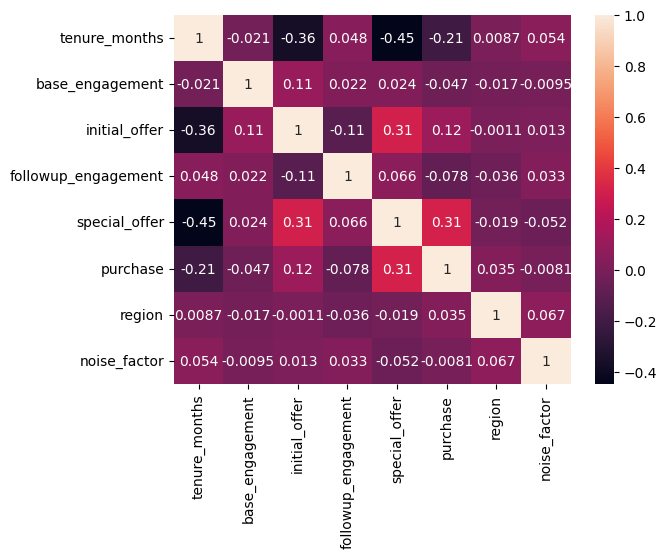

In [72]:
# Example: Plotting a heatmap to show feature correlations
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True)
plt.show()
